# Create initial conditions for MOM6 panan based on Shenjie Zhou's climatology product

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import xarray as xr
import glob,os
import cmocean.cm as cmocean
import xesmf as xe
import gsw

import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client

In [2]:
client = Client(threads_per_worker = 1, memory_limit="12GB")
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 312.92 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39075,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35125,Total threads: 1
Dashboard: /proxy/34563/status,Memory: 11.18 GiB
Nanny: tcp://127.0.0.1:39087,


## Importing Zhou et al. climatology data
Note this has no time dimension.

See paper: https://essd.copernicus.org/preprints/essd-2025-727/

And data: https://www.seanoe.org/data/00928/103946/

In [3]:
shenjie_path = '/g/data/x77/cy8964/ocean-ice-obs/OI_Climatology.nc'
shenjie_data = xr.open_dataset(shenjie_path)

# has no coords:
shenjie_data = shenjie_data.set_coords(["pressure","longitude","latitude"])

# remove scalars on coords:
shenjie_data["latitude"] = shenjie_data.latitude.isel(SCALAR=0)
shenjie_data["longitude"] = shenjie_data.longitude.isel(SCALAR=0)
shenjie_data["pressure"] = shenjie_data.pressure.isel(SCALAR=0)

# swap lat/lon:
shenjie_data = shenjie_data.transpose("nz","ny","nx")

# overwrite dimensions to be same as coordinates (rather than indices)
shenjie_data = shenjie_data.swap_dims({"nz":"pressure"})
shenjie_data = shenjie_data.swap_dims({"nx":"longitude"})
shenjie_data = shenjie_data.swap_dims({"ny":"latitude"})

shenjie_data = shenjie_data.drop_vars(["ct_mse","sa_mse"])

shenjie_data = shenjie_data.chunk({"pressure": 201, "latitude": 226, "longitude": 301})

shenjie_data
#shenjie_data.load()

<xarray.Dataset> Size: 8GB
Dimensions:    (latitude: 451, longitude: 1801, pressure: 601)
Coordinates:
  * latitude   (latitude) float64 4kB -90.0 -89.9 -89.8 ... -45.2 -45.1 -45.0
  * longitude  (longitude) float64 14kB -180.0 -179.8 -179.6 ... 179.8 180.0
  * pressure   (pressure) float64 5kB 5.0 15.0 25.0 ... 5.995e+03 6.005e+03
Data variables:
    ct         (pressure, latitude, longitude) float64 4GB dask.array<chunksize=(201, 226, 301), meta=np.ndarray>
    sa         (pressure, latitude, longitude) float64 4GB dask.array<chunksize=(201, 226, 301), meta=np.ndarray>
Attributes:
    Authors:        Shenjie Zhou, shezhou@bas.ac.uk
    Creation Date:  16-Oct-2025
    Description:    OCEAN:ICE D1.1 - Southern Ocean Climatology (annual mean) v2

In [4]:
# shift longitude of Shenjie data to match model grid:
# This cell is slow. I also tried sortby() but that was also slow.

# Before doing this, we need to remove the eastern-most longitude value, 
# because it is a copy of the western-most:
shenjie_data = shenjie_data.isel(longitude=slice(0,-1))

wrap_index = int(np.where(shenjie_data.longitude>80)[0][0])

shenjie_data_wrapped = shenjie_data.roll(longitude=-wrap_index, roll_coords=True)
shenjie_data_wrapped['longitude'] = shenjie_data_wrapped.longitude.where(shenjie_data_wrapped.longitude<=80, other=shenjie_data_wrapped.longitude-360)
shenjie_data_wrapped

<xarray.Dataset> Size: 8GB
Dimensions:    (latitude: 451, longitude: 1800, pressure: 601)
Coordinates:
  * latitude   (latitude) float64 4kB -90.0 -89.9 -89.8 ... -45.2 -45.1 -45.0
  * longitude  (longitude) float64 14kB -279.8 -279.6 -279.4 ... 79.6 79.8 80.0
  * pressure   (pressure) float64 5kB 5.0 15.0 25.0 ... 5.995e+03 6.005e+03
Data variables:
    ct         (pressure, latitude, longitude) float64 4GB dask.array<chunksize=(201, 226, 301), meta=np.ndarray>
    sa         (pressure, latitude, longitude) float64 4GB dask.array<chunksize=(201, 226, 301), meta=np.ndarray>
Attributes:
    Authors:        Shenjie Zhou, shezhou@bas.ac.uk
    Creation Date:  16-Oct-2025
    Description:    OCEAN:ICE D1.1 - Southern Ocean Climatology (annual mean) v2

In [5]:
# Convert from conservative temperature to potential temperature, 
# and absolute salinity to practical salinity:

shenjie_data_wrapped['prac_salinity'] = gsw.SP_from_SA(shenjie_data_wrapped.sa, shenjie_data_wrapped.pressure,
                                                  shenjie_data_wrapped.longitude, shenjie_data_wrapped.latitude)
shenjie_data_wrapped.prac_salinity.attrs['description'] = 'Practical salinity computed from absolute salinity using gsw.SP_from_SA'
shenjie_data_wrapped['pot_temp'] = gsw.pt_from_CT(shenjie_data_wrapped.sa,shenjie_data_wrapped.ct)
shenjie_data_wrapped.pot_temp.attrs['description'] = 'Potential temperature (degC) computed from absolute salinity and conservative temperature using gsw.pt_from_CT'
shenjie_data_wrapped

<xarray.Dataset> Size: 16GB
Dimensions:        (latitude: 451, longitude: 1800, pressure: 601)
Coordinates:
  * latitude       (latitude) float64 4kB -90.0 -89.9 -89.8 ... -45.1 -45.0
  * longitude      (longitude) float64 14kB -279.8 -279.6 -279.4 ... 79.8 80.0
  * pressure       (pressure) float64 5kB 5.0 15.0 25.0 ... 5.995e+03 6.005e+03
Data variables:
    ct             (pressure, latitude, longitude) float64 4GB dask.array<chunksize=(201, 226, 301), meta=np.ndarray>
    sa             (pressure, latitude, longitude) float64 4GB dask.array<chunksize=(201, 226, 301), meta=np.ndarray>
    prac_salinity  (pressure, latitude, longitude) float64 4GB dask.array<chunksize=(201, 226, 301), meta=np.ndarray>
    pot_temp       (pressure, latitude, longitude) float64 4GB dask.array<chunksize=(201, 226, 301), meta=np.ndarray>
Attributes:
    Authors:        Shenjie Zhou, shezhou@bas.ac.uk
    Creation Date:  16-Oct-2025
    Description:    OCEAN:ICE D1.1 - Southern Ocean Climatology (annual mean) v2

In [6]:
# Need to add depth coordinate before interpolating:

# should depth be a coordinate or variable? It varies with latitude.
shenjie_data_wrapped = shenjie_data_wrapped.assign_coords({'depth': -gsw.z_from_p(shenjie_data_wrapped.pressure, shenjie_data_wrapped.latitude)})
shenjie_data_wrapped.depth.attrs['description'] = 'Depth computed from pressure using gsw.z_from_p'

# Depth varies hardly at all with latitude (i.e. less than model vertical grid), 
# so I think it would be easier for interpolation to make depth independent of latitude:
shenjie_data_wrapped['depth'] = shenjie_data_wrapped.depth.mean("latitude")

# Then swap pressure dimension for depth:
shenjie_data_wrapped = shenjie_data_wrapped.swap_dims({"pressure":"depth"})

shenjie_data_wrapped = shenjie_data_wrapped.drop_vars(["ct","sa","pressure"])

shenjie_data_wrapped

<xarray.Dataset> Size: 8GB
Dimensions:        (latitude: 451, longitude: 1800, depth: 601)
Coordinates:
  * latitude       (latitude) float64 4kB -90.0 -89.9 -89.8 ... -45.1 -45.0
  * longitude      (longitude) float64 14kB -279.8 -279.6 -279.4 ... 79.8 80.0
  * depth          (depth) float64 5kB 4.951 14.85 24.75 ... 5.855e+03 5.865e+03
Data variables:
    prac_salinity  (depth, latitude, longitude) float64 4GB dask.array<chunksize=(201, 226, 301), meta=np.ndarray>
    pot_temp       (depth, latitude, longitude) float64 4GB dask.array<chunksize=(201, 226, 301), meta=np.ndarray>
Attributes:
    Authors:        Shenjie Zhou, shezhou@bas.ac.uk
    Creation Date:  16-Oct-2025
    Description:    OCEAN:ICE D1.1 - Southern Ocean Climatology (annual mean) v2

## Interpolate onto model grid, stitch to old initial conditions north of 45S:

In [ ]:
# Interpolate onto 8 km panan grid:
# Open old initial condition file to get grid:

old_IC_file = '/g/data/vk83/prerelease/configurations/inputs/access-om3/panan-isf.4km/2026.01.08/ocean_temp_salt.res.nc'
target_grid = xr.open_mfdataset(old_IC_file,chunks={"nyp": 361, "nxp": 300})

# First interpolate vertically onto model grid:
vertical_interp = shenjie_data_wrapped.interp(depth = target_grid.depth, method = 'linear')
vertical_interp = vertical_interp.load()

# Then interpolate horizontally:
initial_conditions_for_8km = vertical_interp.interp(latitude = target_grid.nyp, longitude = target_grid.nxp, method = 'linear')
#initial_conditions_for_8km = initial_conditions_for_8km.load()
initial_conditions_for_8km

In [ ]:
# Stitch old ACCESS-OM2-01 year 2 initial conditions north of 45deg:
# (northern limit of Zhou et al. climatology):

stitched_init_cond = target_grid.copy()
stitched_init_cond["temp"].loc[dict(nyp=slice(None,-45))] = initial_conditions_for_8km.pot_temp.sel(nyp=slice(None,-45))
stitched_init_cond["salt"].loc[dict(nyp=slice(None,-45))] = initial_conditions_for_8km.prac_salinity.sel(nyp=slice(None,-45))
stitched_init_cond.compute()

In [ ]:
del initial_conditions_for_8km, vertical_interp, target_grid, shenjie_data

In [11]:
# save this stage:

enc_TS = {"_FillValue": -1.e-20}

stitched_init_cond.to_netcdf("/g/data/g40/akm157/inputs/mom6/om3_panan_ice_shelf/init_cond_not_extrapolated.nc", encoding={"temp": enc_TS, "salt": enc_TS})


In [3]:
# If already saved, can reopen here instead of doing above calculation:
not_extrap_IC_file = '/g/data/g40/akm157/inputs/mom6/om3_panan_ice_shelf/init_cond_not_extrapolated.nc'
stitched_init_cond = xr.open_mfdataset(not_extrap_IC_file,chunks={"nyp": 361, "nxp": 432})
stitched_init_cond

<xarray.Dataset> Size: 7GB
Dimensions:  (depth: 75, nyp: 1442, nxp: 4320)
Coordinates:
  * depth    (depth) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03
  * nyp      (nyp) float64 12kB -86.49 -86.47 -86.45 ... -37.63 -37.56 -37.5
  * nxp      (nxp) float64 35kB -280.0 -279.9 -279.8 ... 79.79 79.88 79.96
    month    int32 4B ...
Data variables:
    salt     (depth, nyp, nxp) float64 4GB dask.array<chunksize=(75, 361, 432), meta=np.ndarray>
    temp     (depth, nyp, nxp) float64 4GB dask.array<chunksize=(75, 361, 432), meta=np.ndarray>
Attributes:
    description:  Regridded for 8km model grid from January of Kaihe Yamazaki...

## Now do extrapolation into cavities/bathymetry:

For most of Antarctica, we want to do the vertical filling first to ensure we are not spreading open ocean T/S onto the continental shelf. But for West Antarctica, this method is bad and results in cold waters in the warm cavities. So we do both approaches and cut out the second method (no vertical filling) for West Antarctica to combine with the first (vertical filling).

In [4]:
# Do extrapolation into cavities/bathymetry:

vertical_fill = stitched_init_cond.bfill('depth').ffill('depth')
vertical_fill.compute()

# Note we still need to do an upwards fill here, because Zhou has no data at 0-5 m depth:
# But don't fill downwards here!
no_vertical_fill = stitched_init_cond.bfill('depth')
no_vertical_fill.compute()

<xarray.Dataset> Size: 7GB
Dimensions:  (depth: 75, nxp: 4320, nyp: 1442)
Coordinates:
  * depth    (depth) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03
  * nxp      (nxp) float64 35kB -280.0 -279.9 -279.8 ... 79.79 79.88 79.96
  * nyp      (nyp) float64 12kB -86.49 -86.47 -86.45 ... -37.63 -37.56 -37.5
    month    int32 4B 1
Data variables:
    salt     (depth, nyp, nxp) float64 4GB nan nan nan nan ... 34.73 34.72 34.72
    temp     (depth, nyp, nxp) float64 4GB nan nan nan nan ... 1.345 1.135 1.135
Attributes:
    description:  Regridded for 8km model grid from January of Kaihe Yamazaki...

In [5]:
# Function to fill in empty values horizontally using nearest neighbour:

from scipy import ndimage

# Define a function to calculate the nearest valid pixel using SciPy:
def fill_nearest_ocean(data_array):
    # Force inputs to standard NumPy arrays to prevent xarray/dask list leaks
    data_array = np.asarray(data_array)
    num_rows, num_cols = data_array.shape
    
    # Create boolean mask of valid ocean pixels
    valid_mask = ~np.isnan(data_array)
    if not np.any(valid_mask) or np.all(valid_mask):
        return data_array
    
    # Compute 2D coordinate matrices of nearest valid pixels
    _, indices = ndimage.distance_transform_edt(
        ~valid_mask, 
        return_distances=True, 
        return_indices=True
    )
    
    # Unpack row and column spatial grids explicitly
    row_indices = indices[0]
    col_indices = indices[1]
    
    # Safe 1D mathematical flattening (Row * Width + Col)
    flat_indices = row_indices * num_cols + col_indices
    
    # Index into the flattened data array and reshape back to 2D
    return data_array.ravel()[flat_indices].reshape(num_rows, num_cols)


In [6]:
# First for vertically filled arrays:

temp_extrap_vert_fill = xr.apply_ufunc(
    fill_nearest_ocean,
    vertical_fill.temp.drop("month"),
    input_core_dims=[['nyp', 'nxp']],
    output_core_dims=[['nyp', 'nxp']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[stitched_init_cond.temp.dtype],
    dask_gufunc_kwargs={"allow_rechunk": True} 
)
temp_extrap_vert_fill['nyp'] = stitched_init_cond['nyp']
temp_extrap_vert_fill['nxp'] = stitched_init_cond['nxp']
temp_extrap_vert_fill.compute()

salt_extrap_vert_fill = xr.apply_ufunc(
    fill_nearest_ocean,
    vertical_fill.salt.drop("month"),
    input_core_dims=[['nyp', 'nxp']],
    output_core_dims=[['nyp', 'nxp']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[stitched_init_cond.salt.dtype],
    dask_gufunc_kwargs={"allow_rechunk": True} 
)
salt_extrap_vert_fill['nyp'] = stitched_init_cond['nyp']
salt_extrap_vert_fill['nxp'] = stitched_init_cond['nxp']
salt_extrap_vert_fill.compute

<bound method DataArray.compute of <xarray.DataArray 'salt' (depth: 75, nyp: 1442, nxp: 4320)> Size: 4GB
dask.array<transpose, shape=(75, 1442, 4320), dtype=float64, chunksize=(2, 1442, 4320), chunktype=numpy.ndarray>
Coordinates:
  * depth    (depth) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03
  * nyp      (nyp) float64 12kB -86.49 -86.47 -86.45 ... -37.63 -37.56 -37.5
  * nxp      (nxp) float64 35kB -280.0 -279.9 -279.8 ... 79.79 79.88 79.96
    month    int32 4B ...
Attributes:
    label:    practical salinity>

In [7]:
# Then for not vertically filled arrays:

temp_extrap_no_vert_fill = xr.apply_ufunc(
    fill_nearest_ocean,
    no_vertical_fill.temp.drop("month"),
    input_core_dims=[['nyp', 'nxp']],
    output_core_dims=[['nyp', 'nxp']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[stitched_init_cond.temp.dtype],
    dask_gufunc_kwargs={"allow_rechunk": True} 
)
temp_extrap_no_vert_fill['nyp'] = stitched_init_cond['nyp']
temp_extrap_no_vert_fill['nxp'] = stitched_init_cond['nxp']
temp_extrap_no_vert_fill.compute()

salt_extrap_no_vert_fill = xr.apply_ufunc(
    fill_nearest_ocean,
    no_vertical_fill.salt.drop("month"),
    input_core_dims=[['nyp', 'nxp']],
    output_core_dims=[['nyp', 'nxp']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[stitched_init_cond.salt.dtype],
    dask_gufunc_kwargs={"allow_rechunk": True} 
)
salt_extrap_no_vert_fill['nyp'] = stitched_init_cond['nyp']
salt_extrap_no_vert_fill['nxp'] = stitched_init_cond['nxp']
salt_extrap_no_vert_fill.compute

<bound method DataArray.compute of <xarray.DataArray 'salt' (depth: 75, nyp: 1442, nxp: 4320)> Size: 4GB
dask.array<transpose, shape=(75, 1442, 4320), dtype=float64, chunksize=(2, 1442, 4320), chunktype=numpy.ndarray>
Coordinates:
  * depth    (depth) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03
  * nyp      (nyp) float64 12kB -86.49 -86.47 -86.45 ... -37.63 -37.56 -37.5
  * nxp      (nxp) float64 35kB -280.0 -279.9 -279.8 ... 79.79 79.88 79.96
    month    int32 4B ...
Attributes:
    label:    practical salinity>

In [9]:
# Now stitch West Antarctica from no vertical fill array to the other one:

temp_extrap = temp_extrap_vert_fill.copy()
temp_extrap.loc[dict(nyp=slice(-75.7, -62), nxp=slice(-130, -66))] = temp_extrap_no_vert_fill.sel(nyp=slice(-75.7, -62), nxp=slice(-130, -66))

salt_extrap = salt_extrap_vert_fill.copy()
salt_extrap.loc[dict(nyp=slice(-75.7, -62), nxp=slice(-130, -66))] = salt_extrap_no_vert_fill.sel(nyp=slice(-75.7, -62), nxp=slice(-130, -66))

# This looks good!

## Save, writing over existing initial conditions variables to make sure we get correct metadata etc:

In [10]:
# file to overwrite variables:
IC_file = '/g/data/g40/akm157/inputs/mom6/om3_panan_ice_shelf/ocean_temp_salt_Zhou.res.nc'
# then overwrite the variables with the new data:
ncFile = nc.Dataset(IC_file,'r+')
ncFile.variables['salt'][...] = salt_extrap.values
ncFile.variables['temp'][...] = temp_extrap.values
ncFile.close()

## Then plot to compare bottom temp/salt from Shenjie, WOA, old initial conditions, new extrapolated initial conditions:

### Bottom temp:

In [18]:
# Bottom temp:

# Get bottom depth from model grid:
bottom_depth = xr.open_dataset('/g/data/x77/cy8964/mom6/input/input-8km/150925/topog_Charrassin_open_cavity_noGL5m_new150925.nc')

# Extract bottom values for Shenjie data stitched to old IC, not extrapolated:
stitched_init_cond_masked = stitched_init_cond.where(stitched_init_cond*0+stitched_init_cond.depth < bottom_depth.depth.values)
bot_stitched = stitched_init_cond.where((stitched_init_cond_masked*0+stitched_init_cond_masked.depth).max('depth') == stitched_init_cond_masked.depth).sum('depth')
bot_stitched_temp = bot_stitched.temp.where(bot_stitched.temp!=0).compute()

# Extract bottom values for new extrapolated data:
temp_extrap_masked = temp_extrap.where(temp_extrap*0+temp_extrap.depth < bottom_depth.depth.values)
bot_temp_extrap = temp_extrap.where((temp_extrap_masked*0+temp_extrap_masked.depth).max('depth') == temp_extrap_masked.depth).sum('depth')
bot_temp_extrap = bot_temp_extrap.where(bot_temp_extrap!=0).compute()

# Also compare old initial conditions:
old_IC_file = '/g/data/vk83/prerelease/configurations/inputs/access-om3/panan-isf.4km/2026.01.08/ocean_temp_salt.res.nc'
old_IC = xr.open_mfdataset(old_IC_file,chunks={"nyp": 361, "nxp": 300})
old_IC.compute()
old_IC_masked = old_IC.where(old_IC*0+old_IC.depth < bottom_depth.depth.values)
bot_old_IC = old_IC.where((old_IC_masked*0+old_IC_masked.depth).max('depth') == old_IC_masked.depth).sum('depth')
bot_old_IC_temp = bot_old_IC.temp.where(bot_old_IC.temp!=0).compute()

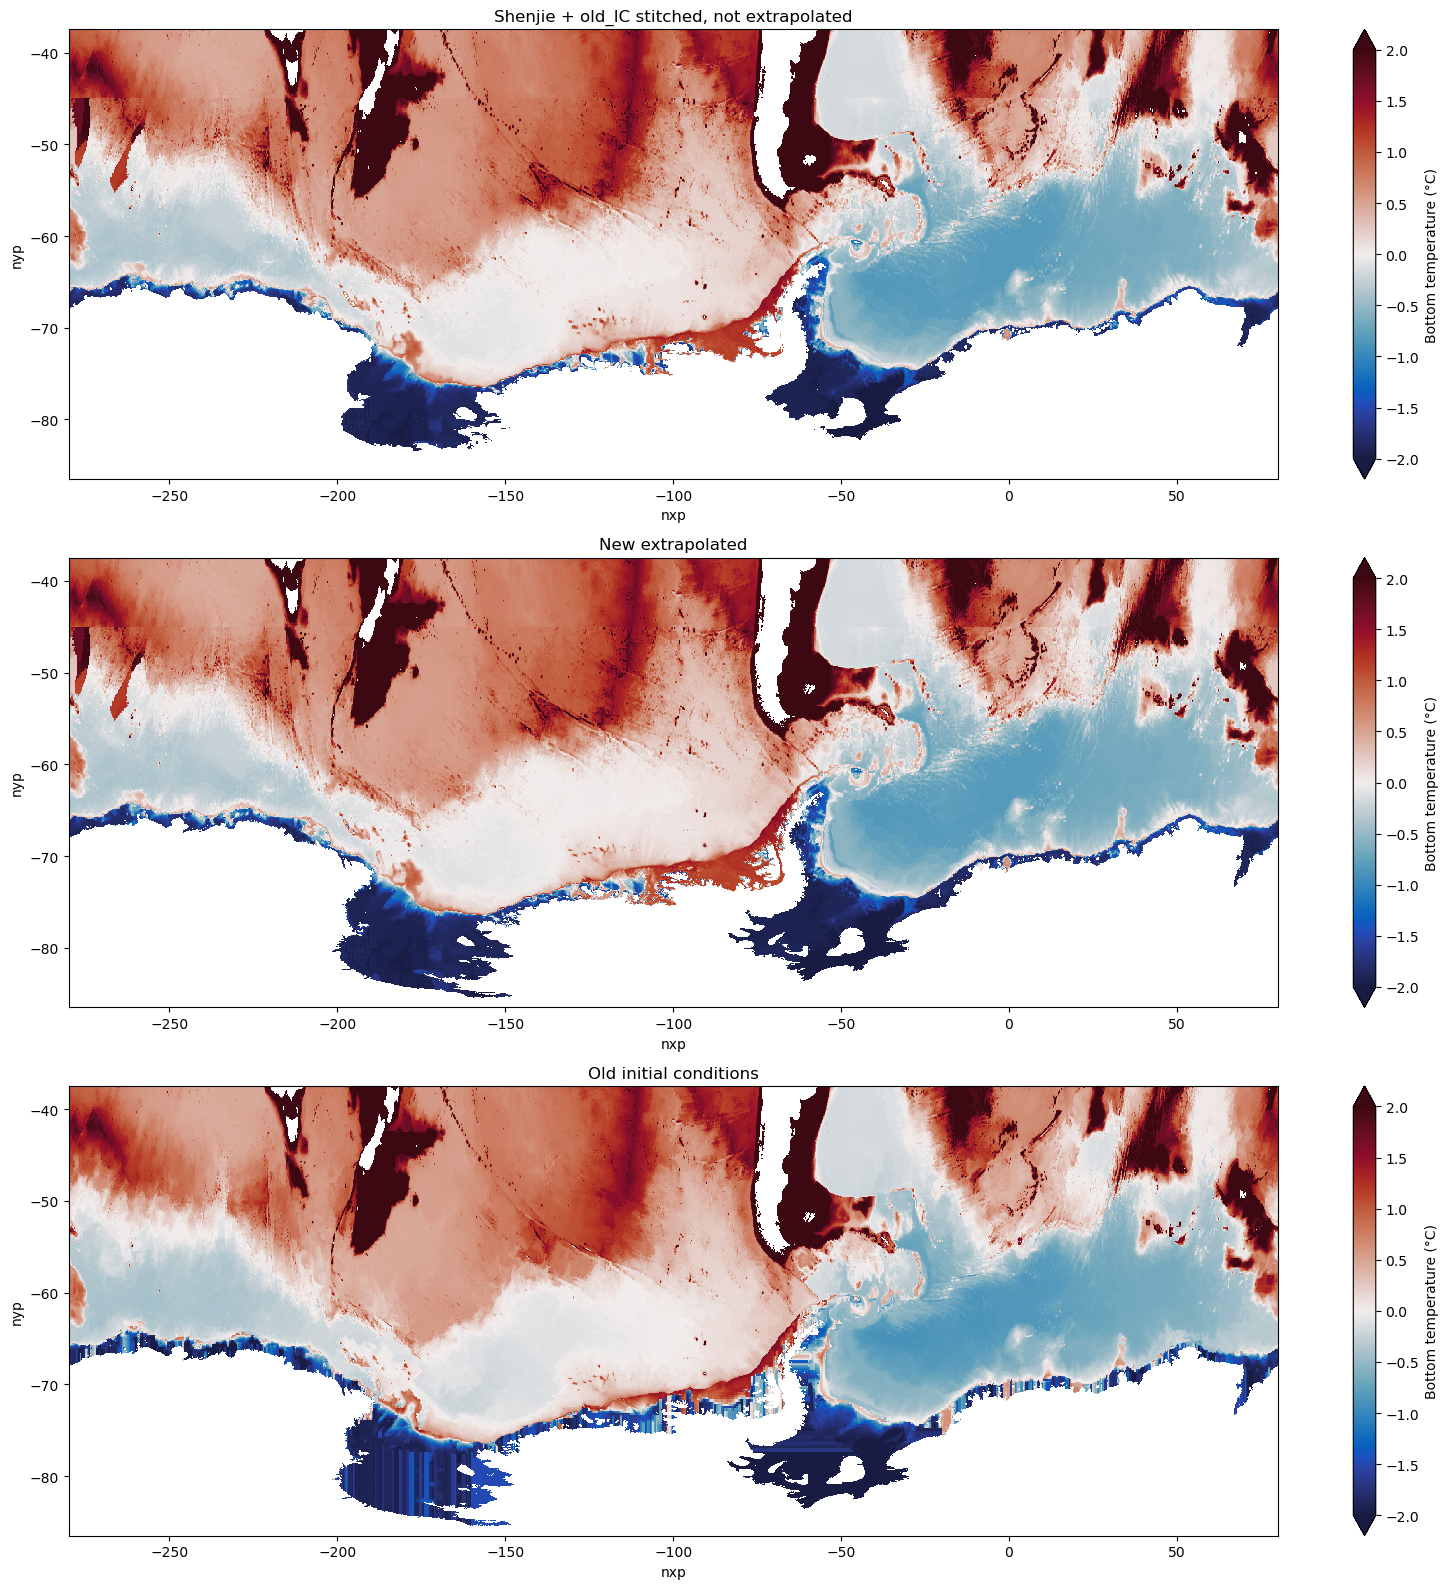

In [19]:
# Plot:
fig, axs = plt.subplots(3, 1, figsize=(16, 16))
# plot Shenjie data stitched to old IC, not extrapolated:
bot_stitched_temp.plot(ax=axs[0],cmap = cmocean.balance, vmax = 2, vmin = -2, 
                                                   cbar_kwargs={'label': 'Bottom temperature (°C)'})
axs[0].set_title('Shenjie + old_IC stitched, not extrapolated')

# Plot new extrapolated data:
bot_temp_extrap.plot(ax=axs[1],cmap = cmocean.balance, vmax = 2, vmin = -2, 
                                                   cbar_kwargs={'label': 'Bottom temperature (°C)'})
axs[1].set_title('New extrapolated')

# Plot old initial conditions:
bot_old_IC_temp.plot(ax=axs[2],cmap = cmocean.balance, vmax = 2, vmin = -2, 
                                                   cbar_kwargs={'label': 'Bottom temperature (°C)'})
axs[2].set_title('Old initial conditions')

plt.tight_layout()

### Bottom temp zoomed on shelf:

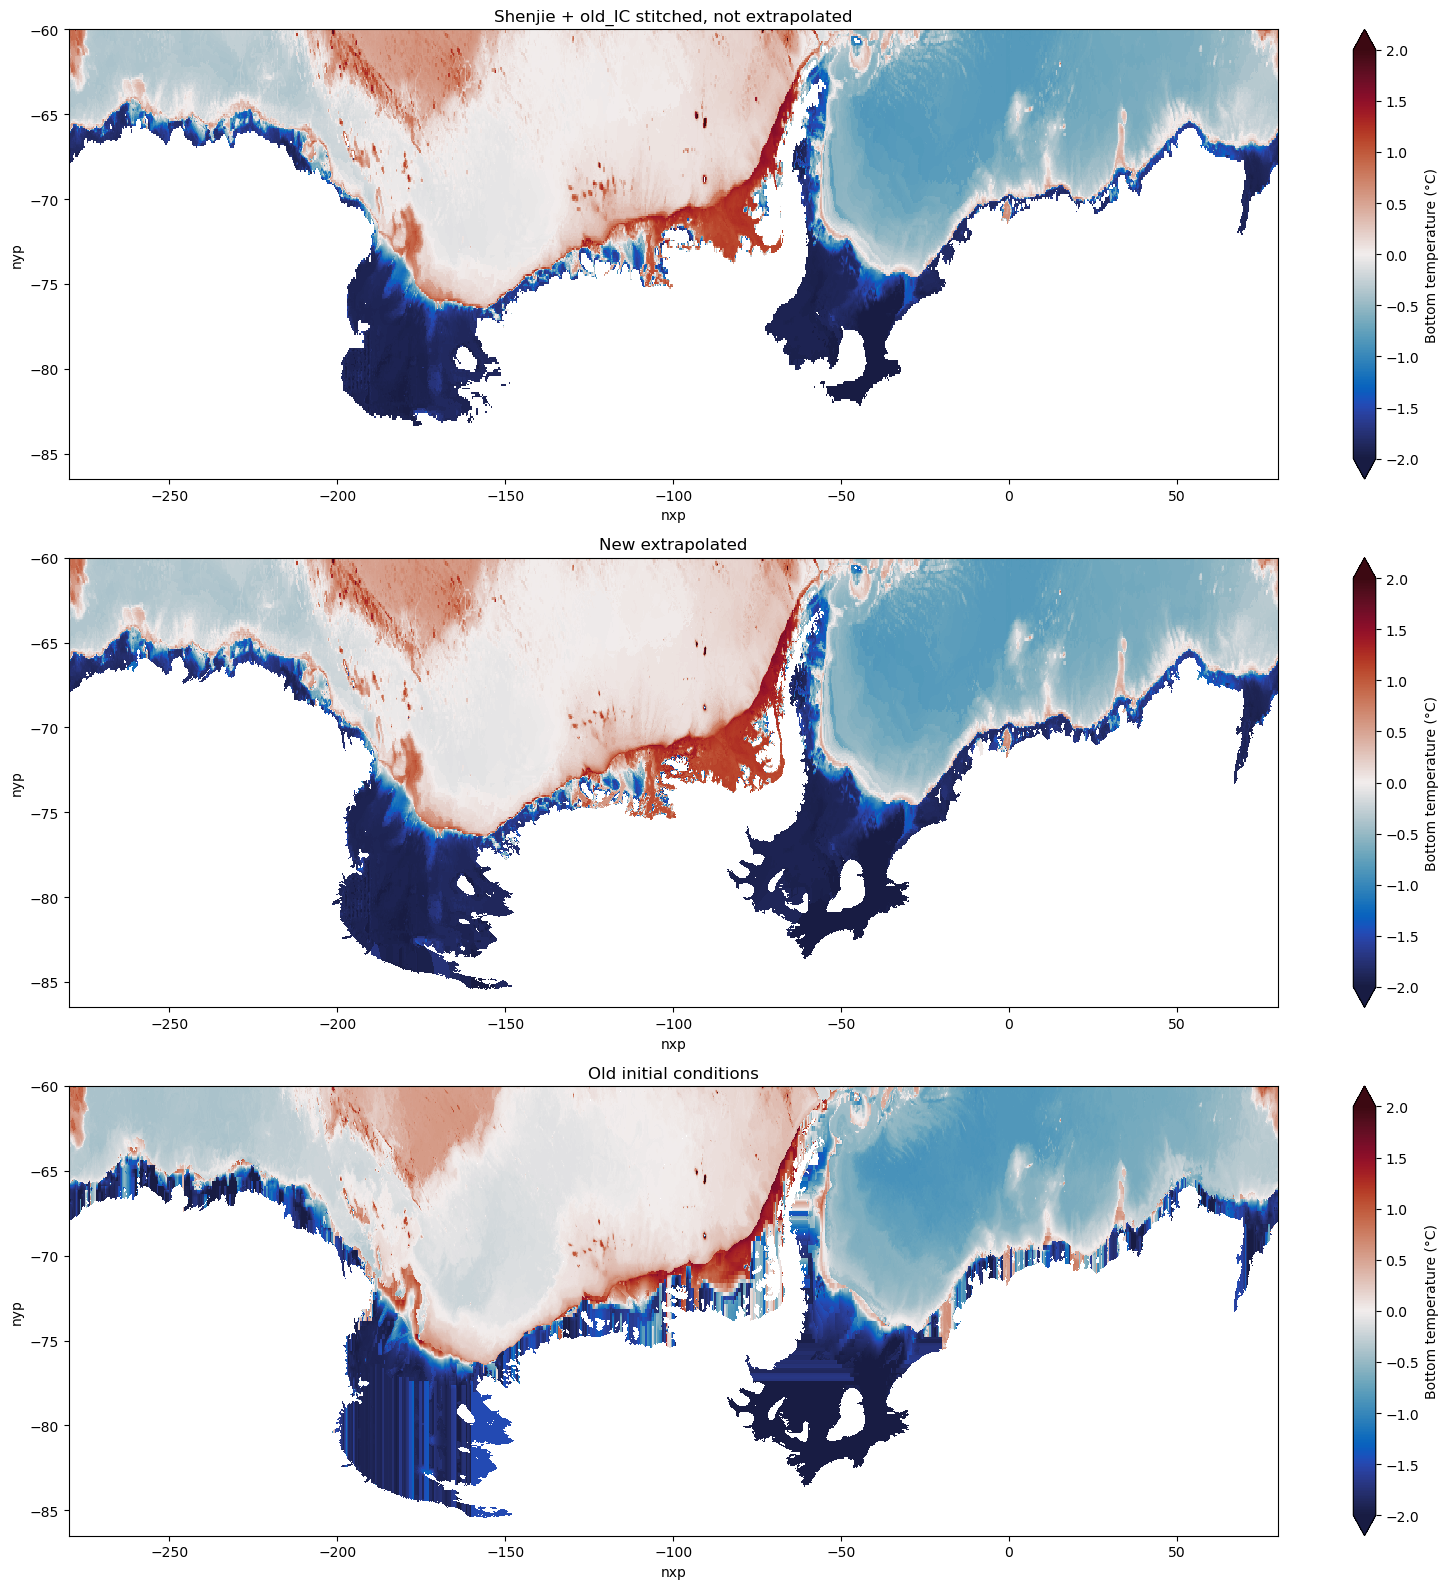

In [20]:
# Plot:
fig, axs = plt.subplots(3, 1, figsize=(16, 16))
# plot Shenjie data stitched to old IC, not extrapolated:
bot_stitched_temp.plot(ax=axs[0],cmap = cmocean.balance, vmax = 2, vmin = -2, 
                                                   cbar_kwargs={'label': 'Bottom temperature (°C)'})
axs[0].set_title('Shenjie + old_IC stitched, not extrapolated')
axs[0].set_ylim(None,-60)

# Plot new extrapolated data:
bot_temp_extrap.plot(ax=axs[1],cmap = cmocean.balance, vmax = 2, vmin = -2, 
                                                   cbar_kwargs={'label': 'Bottom temperature (°C)'})
axs[1].set_title('New extrapolated')
axs[1].set_ylim(None,-60)

# Plot old initial conditions:
bot_old_IC_temp.plot(ax=axs[2],cmap = cmocean.balance, vmax = 2, vmin = -2, 
                                                   cbar_kwargs={'label': 'Bottom temperature (°C)'})
axs[2].set_title('Old initial conditions')
axs[2].set_ylim(None,-60)
    
plt.tight_layout()

### Bottom salinity

In [21]:
# Extract bottom values for Shenjie data stitched to old IC, not extrapolated:
bot_stitched_salt = bot_stitched.salt.where(bot_stitched.salt!=0).compute()

# Extract bottom values for new extrapolated data:
salt_extrap_masked = salt_extrap.where(salt_extrap*0+salt_extrap.depth < bottom_depth.depth.values)
bot_salt_extrap = salt_extrap.where((salt_extrap_masked*0+salt_extrap_masked.depth).max('depth') == salt_extrap_masked.depth).sum('depth')
bot_salt_extrap = bot_salt_extrap.where(bot_salt_extrap!=0).compute()

# Also compare old initial conditions:
bot_old_IC_salt = bot_old_IC.salt.where(bot_old_IC.salt!=0).compute()

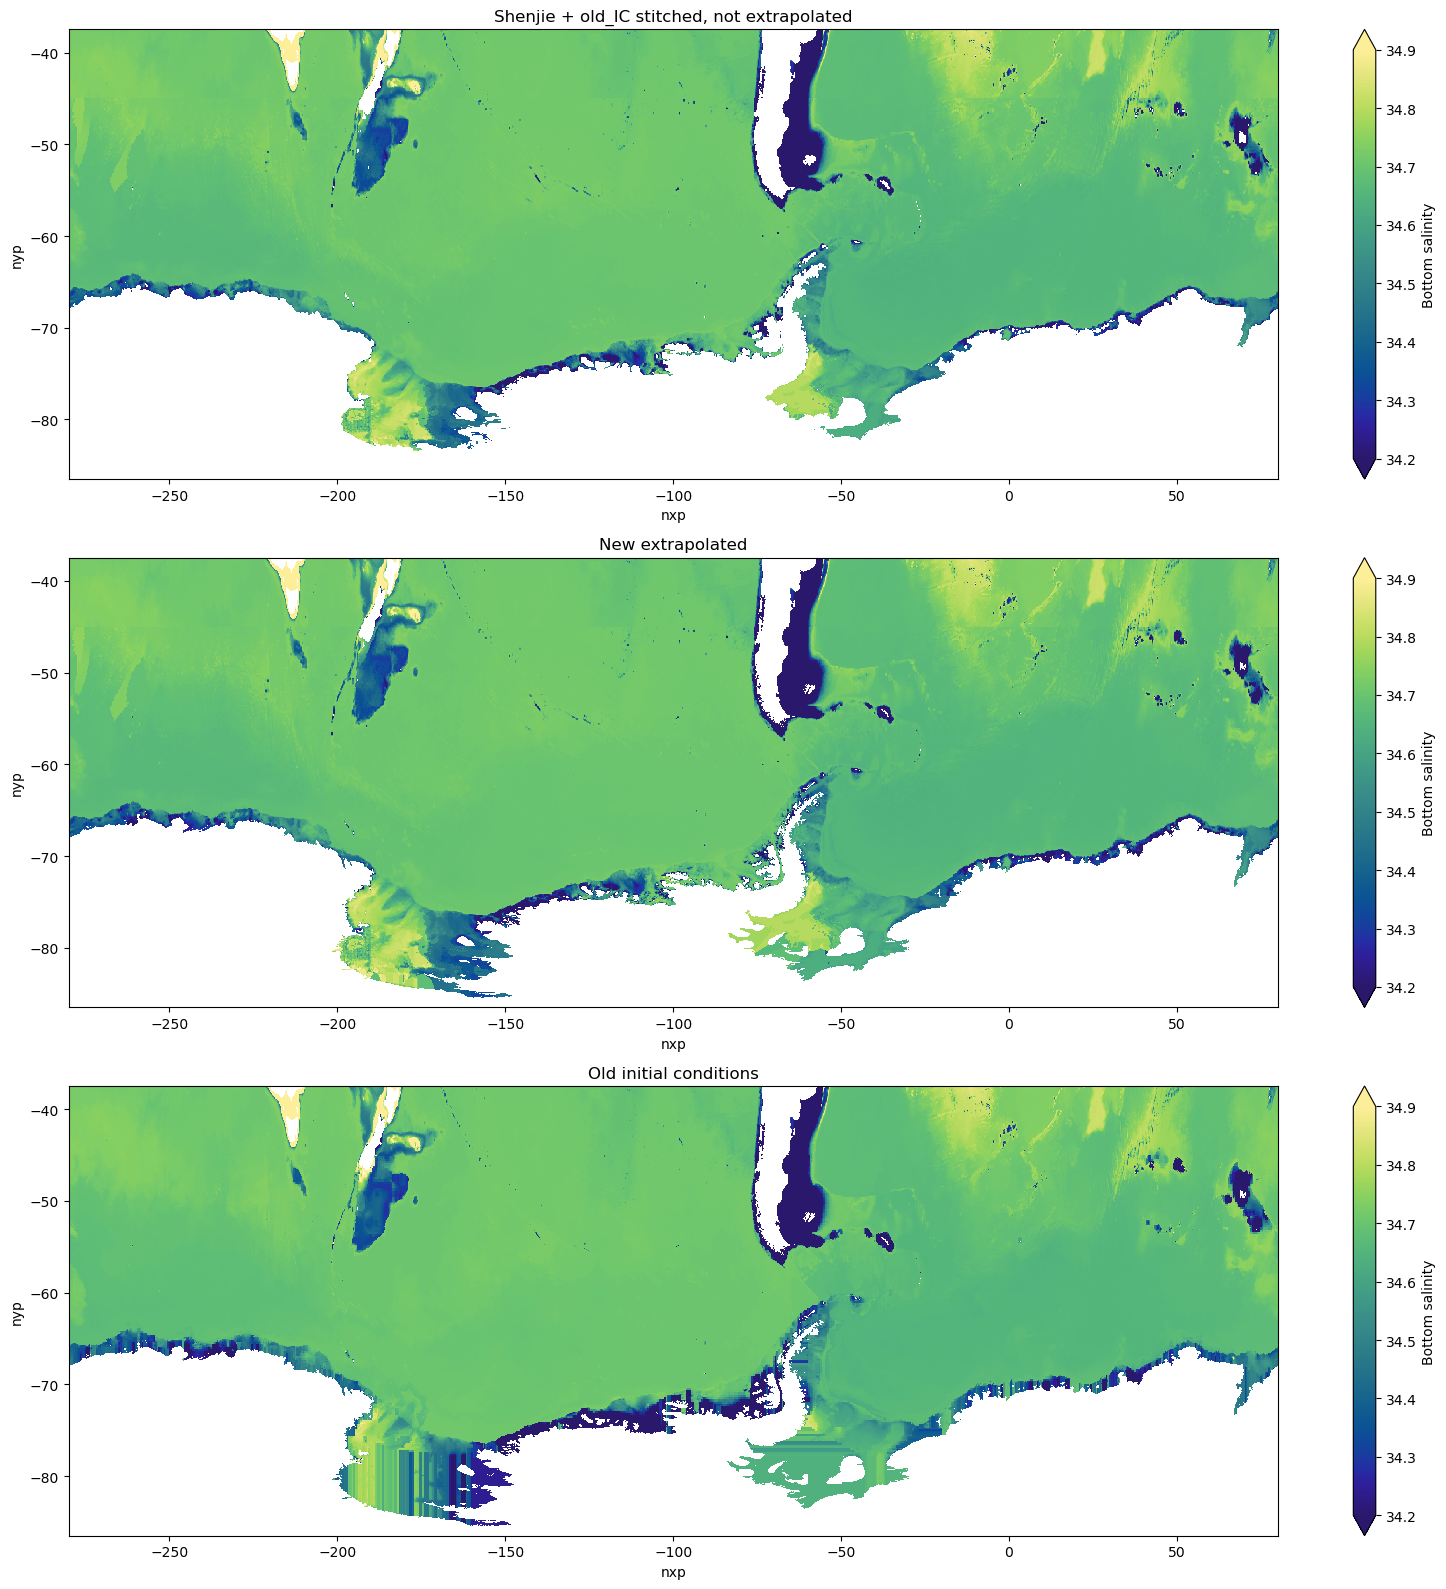

In [22]:
# Plot:
fig, axs = plt.subplots(3, 1, figsize=(16, 16))
# plot Shenjie data stitched to old IC, not extrapolated:
bot_stitched_salt.plot(ax=axs[0],cmap = cmocean.haline, vmax = 34.9, vmin = 34.2, 
                                                   cbar_kwargs={'label': 'Bottom salinity'})
axs[0].set_title('Shenjie + old_IC stitched, not extrapolated')

# Plot new extrapolated data:
bot_salt_extrap.plot(ax=axs[1],cmap = cmocean.haline, vmax = 34.9, vmin = 34.2, 
                                                   cbar_kwargs={'label': 'Bottom salinity'})
axs[1].set_title('New extrapolated')

# Plot old initial conditions:
bot_old_IC_salt.plot(ax=axs[2],cmap = cmocean.haline, vmax = 34.9, vmin = 34.2, 
                                                   cbar_kwargs={'label': 'Bottom salinity'})
axs[2].set_title('Old initial conditions')

plt.tight_layout()

### Temp slice at 500m:

In [23]:
# import topography for coastline:

# ice shelf cavity topography:
topog_path = '/g/data/vk83/prerelease/configurations/inputs/access-om3/panan-isf.4km/2026.01.08/topog.nc'
topog = xr.open_dataset(topog_path)
topog = topog.load()

land_mask = topog.depth.where(topog.depth==0).compute()

# sea ice topography:
topog_seaice_path = '/g/data/vk83/prerelease/configurations/inputs/access-om3/panan-isf.4km/2026.01.08/topog_seaice.nc'
topog_seaice = xr.open_dataset(topog_seaice_path)
topog_seaice = topog_seaice.load()

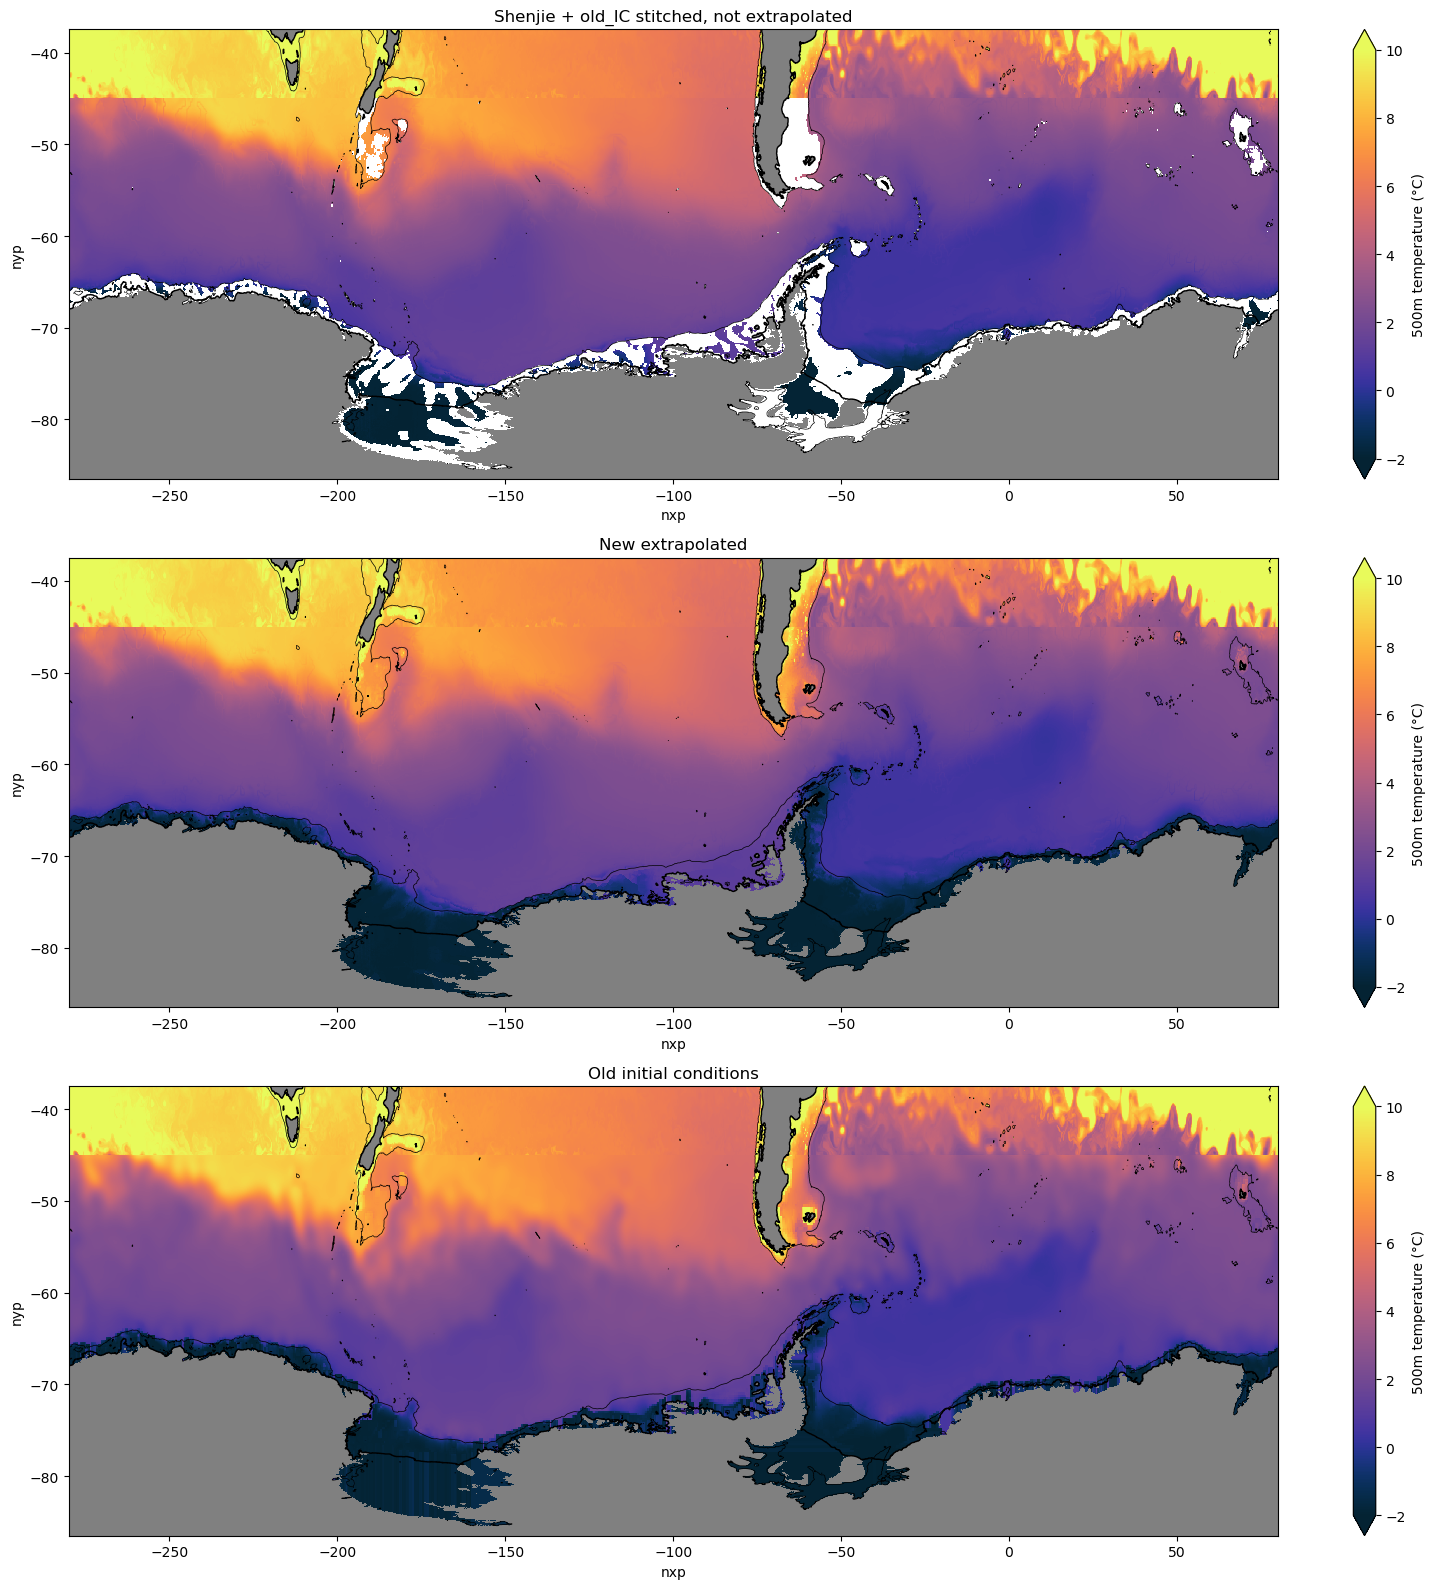

In [24]:
# Plot:
from matplotlib.colors import ListedColormap
solid_grey_cmap = ListedColormap(['grey']) 

fig, axs = plt.subplots(3, 1, figsize=(16, 16))

# plot Shenjie data stitched to old IC, not extrapolated:
stitched_init_cond.temp.sel(depth=500,method='nearest').plot(ax=axs[0],cmap = cmocean.thermal, vmax = 10, vmin = -2, 
                                                   cbar_kwargs={'label': '500m temperature (°C)'})
axs[0].set_title('Shenjie + old_IC stitched, not extrapolated')
axs[0].contour(topog.lon, topog.lat, topog_seaice.depth, levels=[0], colors='k',linewidths=1)
axs[0].contour(topog.lon, topog.lat, topog.depth, levels=[1000], colors='k',linewidths=0.5)
axs[0].pcolormesh(topog.lon,topog.lat,land_mask,cmap=solid_grey_cmap)

# Plot new extrapolated data:
temp_extrap.sel(depth=500,method='nearest').plot(ax=axs[1],cmap = cmocean.thermal, vmax = 10, vmin = -2, 
                                                   cbar_kwargs={'label': '500m temperature (°C)'})
axs[1].set_title('New extrapolated')
axs[1].contour(topog.lon, topog.lat, topog_seaice.depth, levels=[0], colors='k',linewidths=1)
axs[1].contour(topog.lon, topog.lat, topog.depth, levels=[1000], colors='k',linewidths=0.5)
axs[1].pcolormesh(topog.lon,topog.lat,land_mask,cmap=solid_grey_cmap)

# Plot old initial conditions:
old_IC.temp.sel(depth=500,method='nearest').plot(ax=axs[2],cmap = cmocean.thermal, vmax = 10, vmin = -2, 
                                                   cbar_kwargs={'label': '500m temperature (°C)'})
axs[2].set_title('Old initial conditions')
axs[2].contour(topog.lon, topog.lat, topog_seaice.depth, levels=[0], colors='k',linewidths=1)
axs[2].contour(topog.lon, topog.lat, topog.depth, levels=[1000], colors='k',linewidths=0.5)
axs[2].pcolormesh(topog.lon,topog.lat,land_mask,cmap=solid_grey_cmap)

plt.tight_layout()

### Zoom slice at 500m:

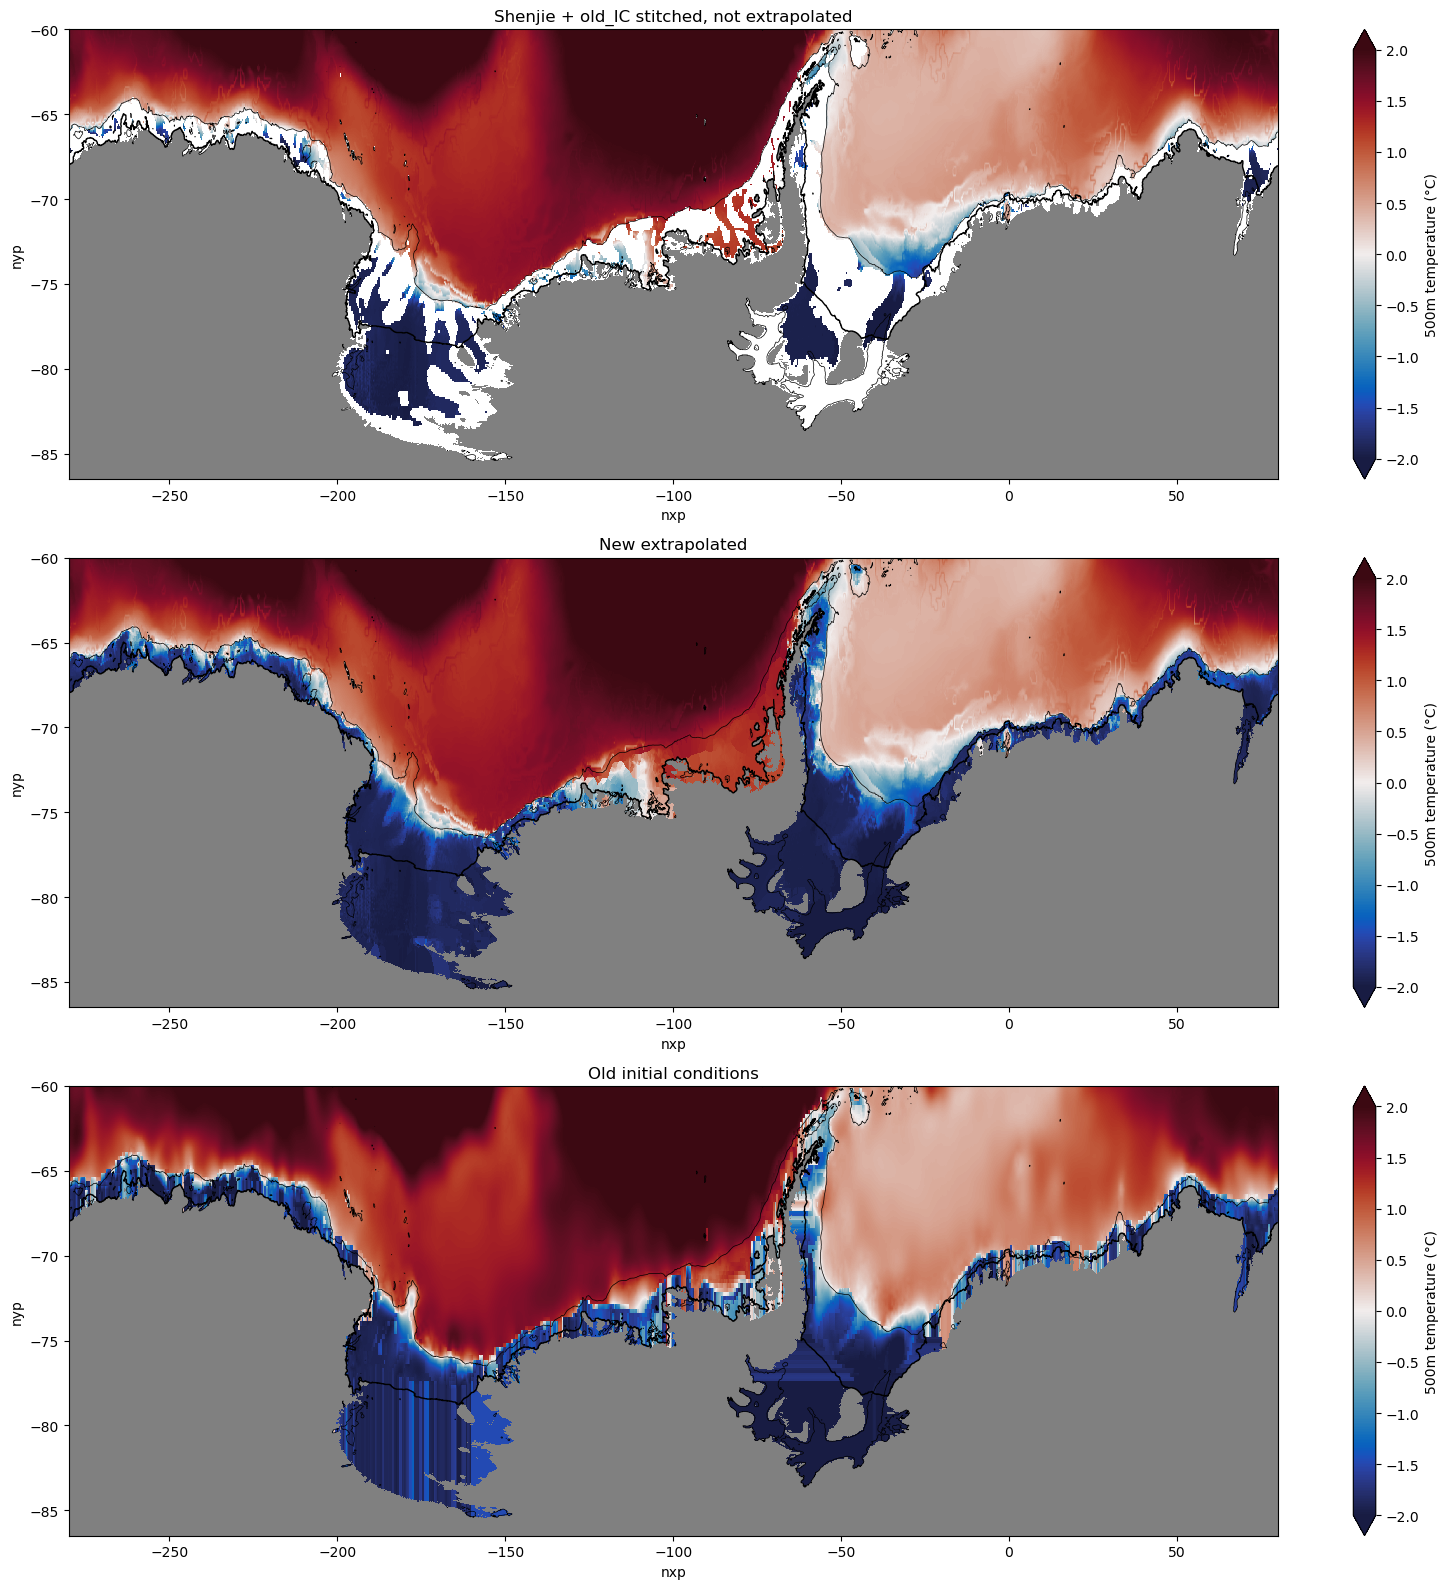

In [25]:
# Plot:

fig, axs = plt.subplots(3, 1, figsize=(16, 16))

# plot Shenjie data stitched to old IC, not extrapolated:
stitched_init_cond.temp.sel(depth=500,method='nearest').plot(ax=axs[0],cmap = cmocean.balance, vmax = 2, vmin = -2, 
                                                   cbar_kwargs={'label': '500m temperature (°C)'})
axs[0].set_title('Shenjie + old_IC stitched, not extrapolated')
axs[0].contour(topog.lon, topog.lat, topog_seaice.depth, levels=[0], colors='k',linewidths=1)
axs[0].contour(topog.lon, topog.lat, topog.depth, levels=[1000], colors='k',linewidths=0.5)
axs[0].pcolormesh(topog.lon,topog.lat,land_mask,cmap=solid_grey_cmap)
axs[0].set_ylim(None,-60)

# Plot new extrapolated data:
temp_extrap.sel(depth=500,method='nearest').plot(ax=axs[1],cmap = cmocean.balance, vmax = 2, vmin = -2, 
                                                   cbar_kwargs={'label': '500m temperature (°C)'})
axs[1].set_title('New extrapolated')
axs[1].contour(topog.lon, topog.lat, topog_seaice.depth, levels=[0], colors='k',linewidths=1)
axs[1].contour(topog.lon, topog.lat, topog.depth, levels=[1000], colors='k',linewidths=0.5)
axs[1].pcolormesh(topog.lon,topog.lat,land_mask,cmap=solid_grey_cmap)
axs[1].set_ylim(None,-60)

# Plot old initial conditions:
old_IC.temp.sel(depth=500,method='nearest').plot(ax=axs[2],cmap = cmocean.balance, vmax = 2, vmin = -2, 
                                                   cbar_kwargs={'label': '500m temperature (°C)'})
axs[2].set_title('Old initial conditions')
axs[2].contour(topog.lon, topog.lat, topog_seaice.depth, levels=[0], colors='k',linewidths=1)
axs[2].contour(topog.lon, topog.lat, topog.depth, levels=[1000], colors='k',linewidths=0.5)
axs[2].pcolormesh(topog.lon,topog.lat,land_mask,cmap=solid_grey_cmap)
axs[2].set_ylim(None,-60)

plt.tight_layout()

### Thwaites transect:

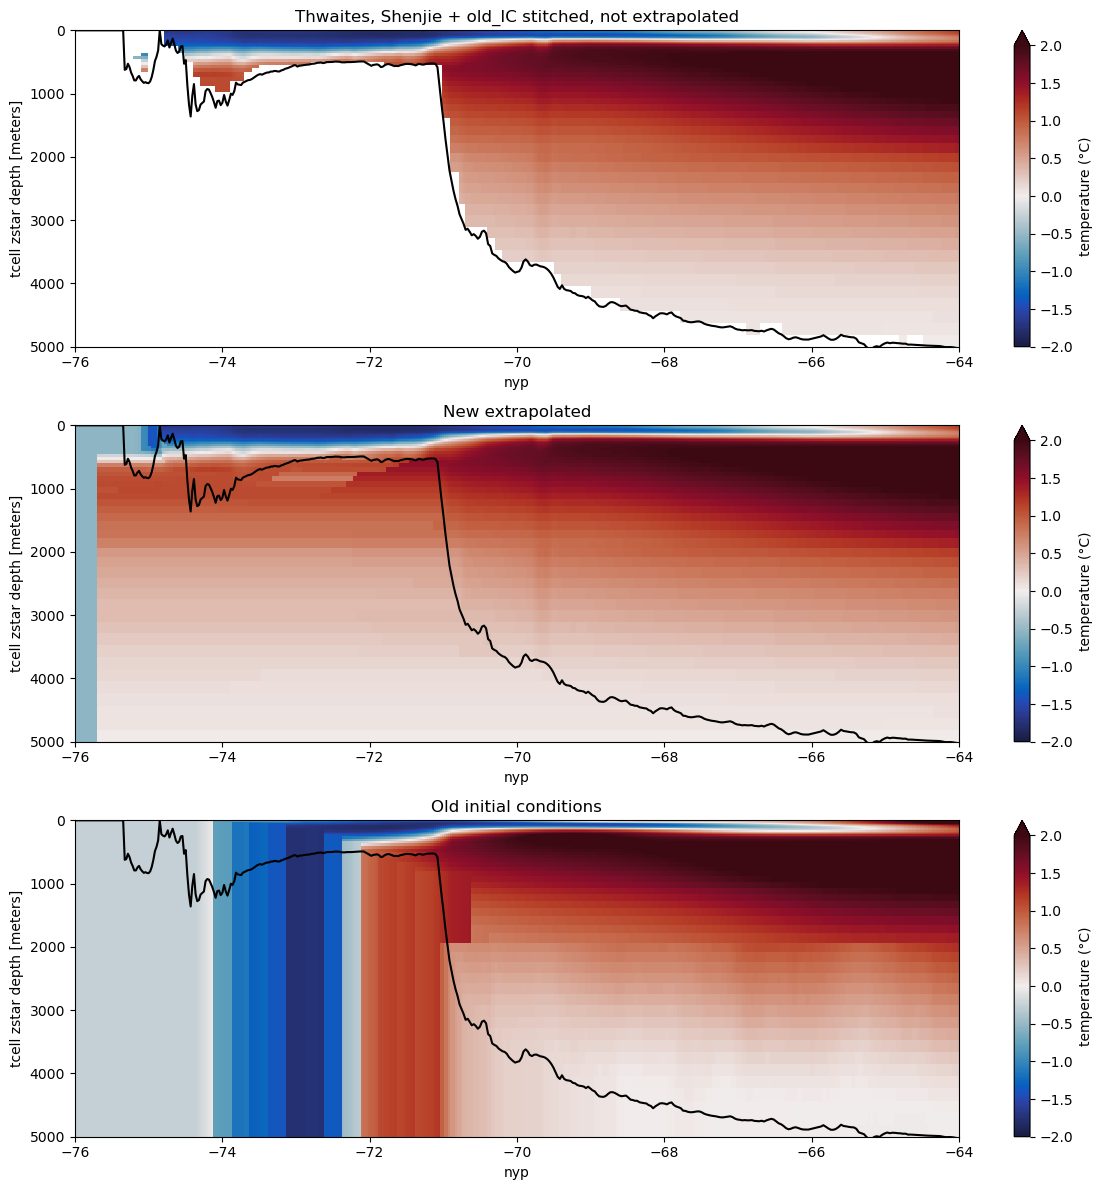

In [36]:
# Plot:
transect_longitude = -106
lat_range = (-76,-64)

fig, axs = plt.subplots(3, 1, figsize=(12, 12))

# plot Shenjie data stitched to old IC, not extrapolated:
stitched_init_cond.temp.sel(nxp=transect_longitude,method='nearest').plot(ax=axs[0],cmap = cmocean.balance, vmax = 2, vmin = -2, 
                                                   cbar_kwargs={'label': 'temperature (°C)'})
axs[0].set_title('Thwaites, Shenjie + old_IC stitched, not extrapolated')
# plot topo:
lon_index = np.where(topog.lon[0]>transect_longitude)[0][0]
axs[0].plot(topog.lat[:,0],topog.depth[:,lon_index],color='k')
axs[0].set_xlim(lat_range)
axs[0].set_ylim(5000,0)

# Plot new extrapolated data:
temp_extrap.sel(nxp=transect_longitude,method='nearest').plot(ax=axs[1],cmap = cmocean.balance, vmax = 2, vmin = -2, 
                                                   cbar_kwargs={'label': 'temperature (°C)'})
axs[1].set_title('New extrapolated')
# plot topo:
axs[1].plot(topog.lat[:,0],topog.depth[:,lon_index],color='k')
axs[1].set_xlim(lat_range)
axs[1].set_ylim(5000,0)

# Plot old initial conditions:
old_IC.temp.sel(nxp=transect_longitude,method='nearest').plot(ax=axs[2],cmap = cmocean.balance, vmax = 2, vmin = -2, 
                                                   cbar_kwargs={'label': 'temperature (°C)'})
axs[2].set_title('Old initial conditions')
# plot topo:
axs[2].plot(topog.lat[:,0],topog.depth[:,lon_index],color='k')
axs[2].set_xlim(lat_range)
axs[2].set_ylim(5000,0)

plt.tight_layout()

### Filchner - Ronne transect

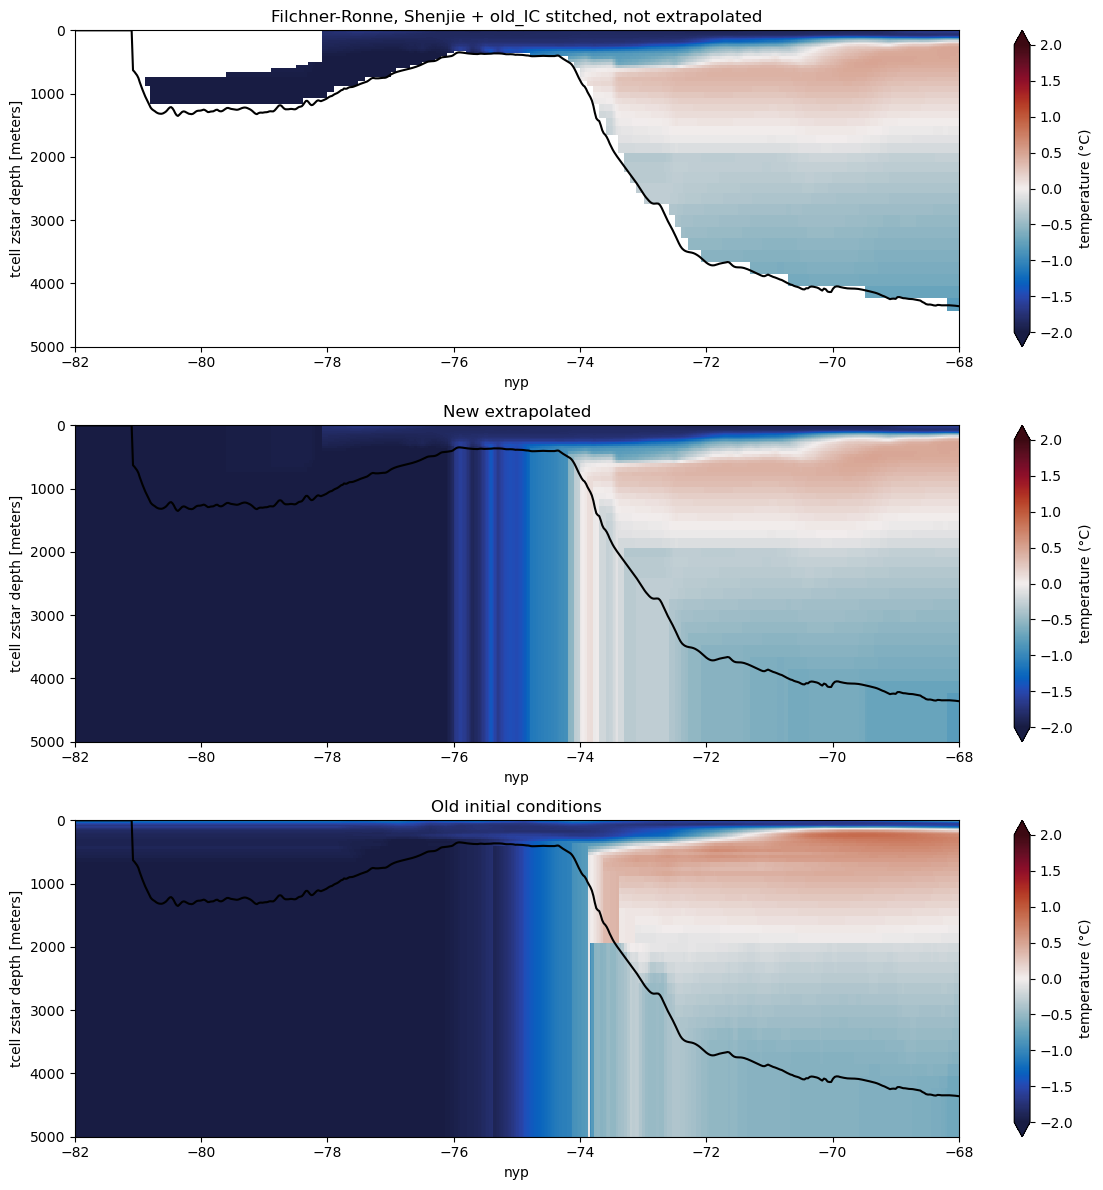

In [37]:
# Plot:
transect_longitude = -40
lat_range = (-82,-68)

fig, axs = plt.subplots(3, 1, figsize=(12, 12))

# plot Shenjie data stitched to old IC, not extrapolated:
stitched_init_cond.temp.sel(nxp=transect_longitude,method='nearest').plot(ax=axs[0],cmap = cmocean.balance, vmax = 2, vmin = -2, 
                                                   cbar_kwargs={'label': 'temperature (°C)'})
axs[0].set_title('Filchner-Ronne, Shenjie + old_IC stitched, not extrapolated')
# plot topo:
lon_index = np.where(topog.lon[0]>transect_longitude)[0][0]
axs[0].plot(topog.lat[:,0],topog.depth[:,lon_index],color='k')
axs[0].set_xlim(lat_range)
axs[0].set_ylim(5000,0)

# Plot new extrapolated data:
temp_extrap.sel(nxp=transect_longitude,method='nearest').plot(ax=axs[1],cmap = cmocean.balance, vmax = 2, vmin = -2, 
                                                   cbar_kwargs={'label': 'temperature (°C)'})
axs[1].set_title('New extrapolated')
# plot topo:
axs[1].plot(topog.lat[:,0],topog.depth[:,lon_index],color='k')
axs[1].set_xlim(lat_range)
axs[1].set_ylim(5000,0)

# Plot old initial conditions:
old_IC.temp.sel(nxp=transect_longitude,method='nearest').plot(ax=axs[2],cmap = cmocean.balance, vmax = 2, vmin = -2, 
                                                   cbar_kwargs={'label': 'temperature (°C)'})
axs[2].set_title('Old initial conditions')
# plot topo:
axs[2].plot(topog.lat[:,0],topog.depth[:,lon_index],color='k')
axs[2].set_xlim(lat_range)
axs[2].set_ylim(5000,0)

plt.tight_layout()

### Ross:

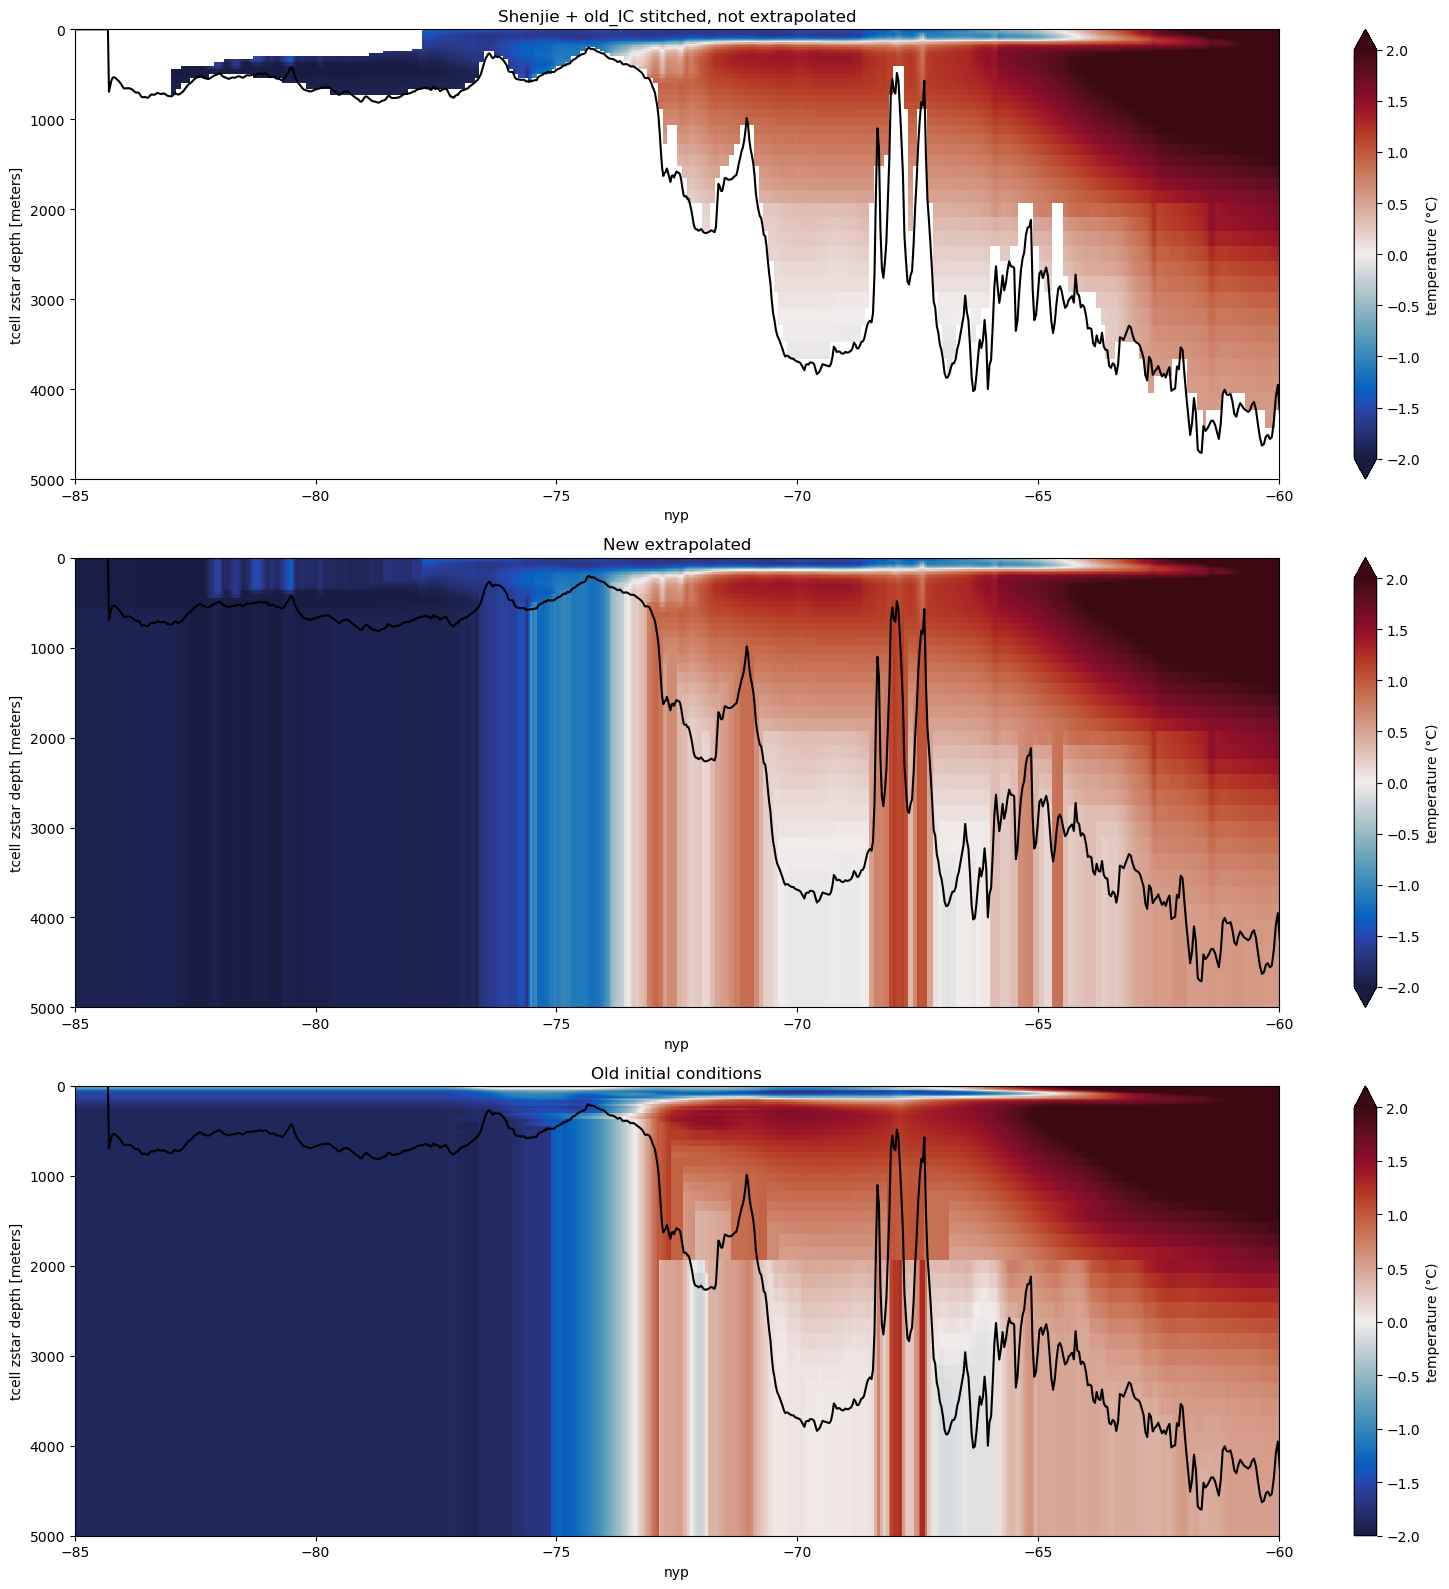

In [40]:
# Plot:
transect_longitude = -180
lat_range = (-85,-60)

fig, axs = plt.subplots(3, 1, figsize=(16, 16))

# plot Shenjie data stitched to old IC, not extrapolated:
stitched_init_cond.temp.sel(nxp=transect_longitude,method='nearest').plot(ax=axs[0],cmap = cmocean.balance, vmax = 2, vmin = -2, 
                                                   cbar_kwargs={'label': 'temperature (°C)'})
axs[0].set_title('Shenjie + old_IC stitched, not extrapolated')
# plot topo:
lon_index = np.where(topog.lon[0]>transect_longitude)[0][0]
axs[0].plot(topog.lat[:,0],topog.depth[:,lon_index],color='k')
axs[0].set_xlim(lat_range)
axs[0].set_ylim(5000,0)

# Plot new extrapolated data:
temp_extrap.sel(nxp=transect_longitude,method='nearest').plot(ax=axs[1],cmap = cmocean.balance, vmax = 2, vmin = -2, 
                                                   cbar_kwargs={'label': 'temperature (°C)'})
axs[1].set_title('New extrapolated')
# plot topo:
axs[1].plot(topog.lat[:,0],topog.depth[:,lon_index],color='k')
axs[1].set_xlim(lat_range)
axs[1].set_ylim(5000,0)

# Plot old initial conditions:
old_IC.temp.sel(nxp=transect_longitude,method='nearest').plot(ax=axs[2],cmap = cmocean.balance, vmax = 2, vmin = -2, 
                                                   cbar_kwargs={'label': 'temperature (°C)'})
axs[2].set_title('Old initial conditions')
# plot topo:
axs[2].plot(topog.lat[:,0],topog.depth[:,lon_index],color='k')
axs[2].set_xlim(lat_range)
axs[2].set_ylim(5000,0)

plt.tight_layout()

### Antarctic peninsula:

In [47]:
topog.lat[:,0]

<xarray.DataArray 'lat' (ny: 1442)> Size: 6kB
array([-86.48922 , -86.46766 , -86.446106, ..., -37.627895, -37.561867,
       -37.49578 ], shape=(1442,), dtype=float32)
Dimensions without coordinates: ny

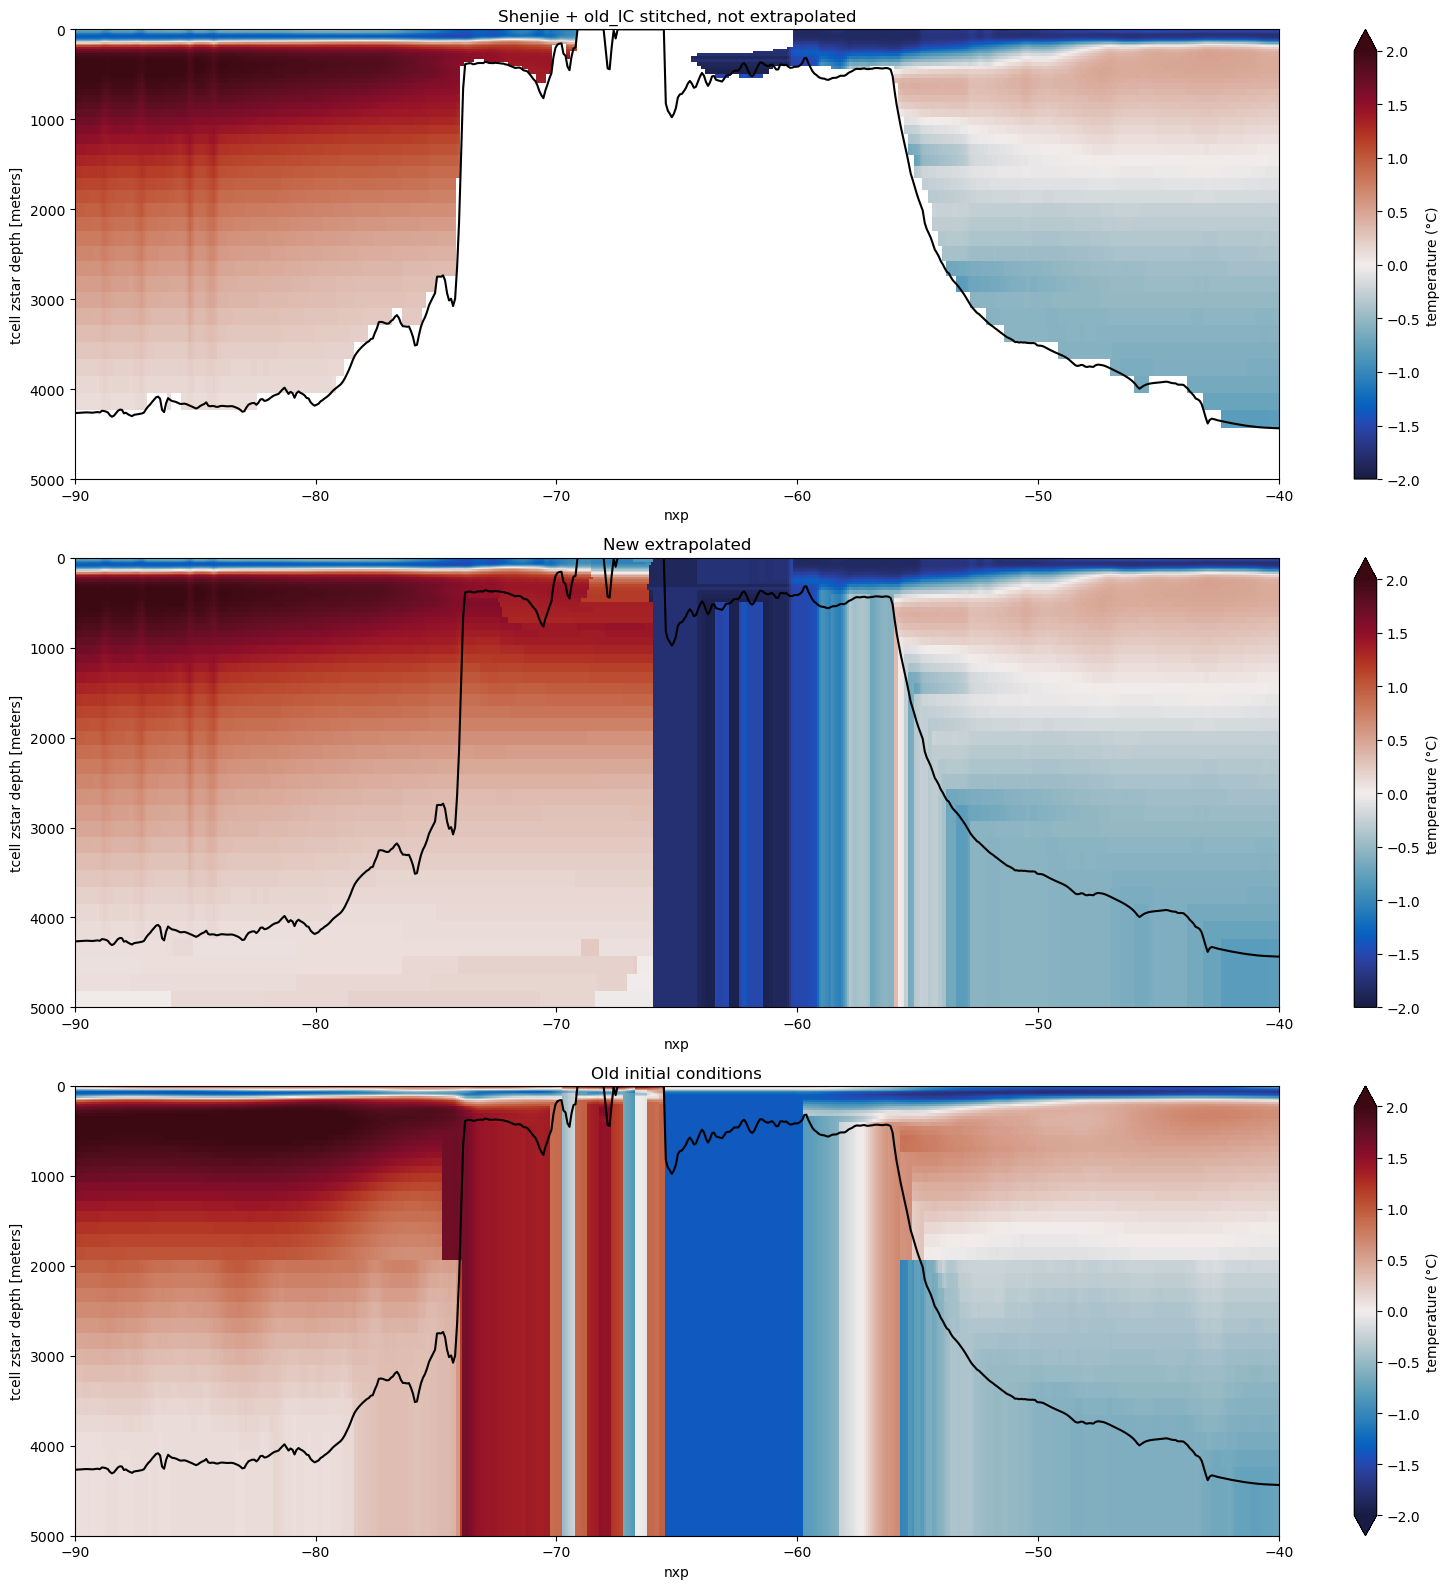

In [49]:
# Plot:
transect_latitude = -67.5
lon_range = (-90,-40)

fig, axs = plt.subplots(3, 1, figsize=(16, 16))

# plot Shenjie data stitched to old IC, not extrapolated:
stitched_init_cond.temp.sel(nyp=transect_latitude,method='nearest').plot(ax=axs[0],cmap = cmocean.balance, vmax = 2, vmin = -2, 
                                                   cbar_kwargs={'label': 'temperature (°C)'})
axs[0].set_title('Peninsula, Shenjie + old_IC stitched, not extrapolated')
# plot topo:
lat_index = np.where(topog.lat[:,0]>transect_latitude)[0][0]
axs[0].plot(topog.lon[0,:],topog.depth[lat_index,:],color='k')
axs[0].set_xlim(lon_range)
axs[0].set_ylim(5000,0)

# Plot new extrapolated data:
temp_extrap.sel(nyp=transect_latitude,method='nearest').plot(ax=axs[1],cmap = cmocean.balance, vmax = 2, vmin = -2, 
                                                   cbar_kwargs={'label': 'temperature (°C)'})
axs[1].set_title('New extrapolated')
# plot topo:
axs[1].plot(topog.lon[0,:],topog.depth[lat_index,:],color='k')
axs[1].set_xlim(lon_range)
axs[1].set_ylim(5000,0)

# Plot old initial conditions:
old_IC.temp.sel(nyp=transect_latitude,method='nearest').plot(ax=axs[2],cmap = cmocean.balance, vmax = 2, vmin = -2, 
                                                   cbar_kwargs={'label': 'temperature (°C)'})
axs[2].set_title('Old initial conditions')
# plot topo:
axs[2].plot(topog.lon[0,:],topog.depth[lat_index,:],color='k')
axs[2].set_xlim(lon_range)
axs[2].set_ylim(5000,0)

plt.tight_layout()